# Análise Exploratória — Alfabetização nos Municípios Brasileiros

**Tech Challenge Fase 3 · POSTECH AI Scientist**

## O que é o Indicador Criança Alfabetizada

O **Compromisso Nacional Criança Alfabetizada (CNCA)** pactua metas por município para que toda
criança esteja alfabetizada ao fim do **2º ano do ensino fundamental**. A régua é o Saeb: a
criança que atinge **743 pontos na escala de Língua Portuguesa** é considerada alfabetizada, e o
**ICA** é o percentual de estudantes que chegam lá.

## Pergunta norteadora

> *"Quais fatores explicam a diferença de alfabetização entre os municípios brasileiros, e onde
> uma criança tem menor chance de sair alfabetizada do 2º ano?"*

## Como este notebook está organizado

Cada etapa responde a uma pergunta cuja resposta **muda a modelagem**. Se a análise não muda
nenhuma decisão, ela não deveria estar aqui.

| Etapa | Pergunta | Decisão que depende dela |
|---|---|---|
| 2 | Que dados temos, e eles estão limpos? | viabilidade da base e estratégia de imputação |
| 3 | Que forma tem o alvo? | onde cortar o rótulo de risco e quais métricas usar |
| 4 | O território explica quanto? | incluir UF; qual ciclo modelar |
| 5 | Quais variáveis carregam sinal? | valor do enriquecimento externo |
| 6 | Há confundimento entre preditores? | necessidade de controlar por região |
| 7 | Há multicolinearidade? | categorias de referência e regularização |
| 8 | O passado prevê o presente? | usar o histórico como preditor |
| 9 | O que isso tudo decide? | hipóteses e decisões de modelagem |

## Etapa 1 — Importando as bibliotecas

In [1]:
# ============================================================
# 1. IMPORTANDO AS BIBLIOTECAS
# ============================================================

import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml
from src.visualization import (MUDO, NEGATIVO, SERIE, TINTA_2, aplicar_estilo,
                               limpar, num, salvar)

warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

IMAGENS = RAIZ / "images"; IMAGENS.mkdir(exist_ok=True)

## Etapa 2 — Inspecionando a base: tamanho, tipos, nulos e estatística descritiva

A passagem padrão pelos dados antes de qualquer análise: as primeiras linhas, o tamanho, os tipos,
os valores ausentes e a estatística descritiva.

In [2]:
# ============================================================
# 2. CARREGANDO A BASE E OLHANDO AS PRIMEIRAS LINHAS
# ============================================================

base = carregar_base_ml().drop(columns=["_gold_processed_at"])
base.head()

,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,afd_ai_grupo_1,afd_ai_grupo_2,afd_ai_grupo_3,afd_ai_grupo_4,afd_ai_grupo_5,atu_creche,atu_pre_escola,atu_anos_iniciais,atu_1_ano,atu_2_ano,ied_ai_nivel_1,ied_ai_nivel_2,ied_ai_nivel_3,ied_ai_nivel_4,ied_ai_nivel_5,ied_ai_nivel_6,media_inse,qtd_alunos_inse,capital_desc,inse_pc_nivel_1,inse_pc_nivel_2,inse_pc_nivel_3,inse_pc_nivel_4,inse_pc_nivel_5,inse_pc_nivel_6,inse_pc_nivel_7,inse_pc_nivel_8,proporcao_rural,ideb_2021,nota_portugues_2021,nota_matematica_2021,indicador_rendimento_2021,taxa_aprovacao_2021,ano
0,1100015,RO,Norte,64.55,67.5,0.0,0.0,2.2,30.3,14.5,20.0,15.2,16.2,17.8,91.2,2.5,0.0,6.3,0.0,0.0,5.0060,281.0,interior,0.00,5.72,17.13,31.25,25.25,13.22,6.18,1.25,0.1459,4.8,181.93,191.69,0.979422,97.8,2023
1,1100023,RO,Norte,62.30,84.1,1.4,11.4,0.6,2.5,19.9,24.0,23.3,22.2,23.4,32.9,21.0,24.1,20.1,1.3,0.6,4.8507,1141.0,interior,0.26,9.54,20.98,29.27,24.30,9.91,5.32,0.41,0.2165,4.5,189.83,200.35,0.866519,87.2,2023
2,1100031,RO,Norte,69.10,100.0,0.0,0.0,0.0,0.0,43.5,16.0,14.2,14.7,13.0,89.3,7.1,3.6,0.0,0.0,0.0,5.2758,49.0,interior,0.00,0.00,14.38,24.67,28.43,14.05,16.34,2.12,0.0000,5.1,190.63,207.16,0.939656,94.9,2023
3,1100049,RO,Norte,62.51,83.2,1.5,7.3,1.8,6.2,14.1,17.3,20.8,22.0,22.4,27.6,17.7,29.4,23.0,1.5,0.8,4.9364,735.0,interior,0.00,6.91,17.50,31.92,25.21,11.94,5.52,1.01,0.4014,5.6,202.35,208.39,0.998998,99.9,2023
4,1100056,RO,Norte,58.53,90.2,0.0,8.2,1.6,0.0,12.2,19.1,20.9,21.6,21.3,73.0,11.1,6.3,4.8,3.2,1.6,4.9469,183.0,interior,0.00,9.14,14.97,28.72,26.62,14.15,5.88,0.51,0.0000,5.5,199.81,206.88,1.000000,100.0,2023


In [3]:
# ============================================================
# 2.1 — TAMANHO DA BASE
# ============================================================

print(f"Tamanho do nosso dataset (linhas, colunas): {base.shape}")
print(f"Municípios distintos: {base['id_municipio'].nunique()}")
print(f"Unidades da federação: {base['sigla_uf'].nunique()}")
print(f"Ciclos avaliativos: {sorted(base['ano'].unique())}")

Tamanho do nosso dataset (linhas, colunas): (10896, 38)
Municípios distintos: 5500
Unidades da federação: 25
Ciclos avaliativos: [np.int64(2023), np.int64(2024)]


In [4]:
# ============================================================
# 2.2 — TIPOS DE DADOS
# ============================================================

base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_municipio               10896 non-null  string 
 1   sigla_uf                   10896 non-null  string 
 2   regiao                     10896 non-null  string 
 3   taxa_alfabetizacao         10896 non-null  float64
 4   afd_ai_grupo_1             10889 non-null  float64
 5   afd_ai_grupo_2             10889 non-null  float64
 6   afd_ai_grupo_3             10889 non-null  float64
 7   afd_ai_grupo_4             10889 non-null  float64
 8   afd_ai_grupo_5             10889 non-null  float64
 9   atu_creche                 10717 non-null  float64
 10  atu_pre_escola             10895 non-null  float64
 11  atu_anos_iniciais          10896 non-null  float64
 12  atu_1_ano                  10894 non-null  float64
 13  atu_2_ano                  10895 non-null  float64
 14  i

In [5]:
# ============================================================
# 2.3 — EXISTEM VALORES NULOS?
# ============================================================

print(f"Quantidade de dados nulos na base: {base.isnull().sum().sum()}")

ausentes = (base.isnull().mean() * 100).sort_values(ascending=False)
ausentes[ausentes > 0].round(2).to_frame("% ausente")

Quantidade de dados nulos na base: 6567


,% ausente
nota_portugues_2021,13.32
nota_matematica_2021,13.32
ideb_2021,13.32
indicador_rendimento_2021,5.03
taxa_aprovacao_2021,5.03
atu_creche,1.64
inse_pc_nivel_8,0.69
proporcao_rural,0.69
capital_desc,0.69
inse_pc_nivel_3,0.69


In [6]:
# ============================================================
# 2.4 — ESTATÍSTICA DESCRITIVA
# ============================================================

colunas_chave = ["taxa_alfabetizacao", "media_inse", "ideb_2021", "qtd_alunos_inse",
                 "afd_ai_grupo_1", "atu_anos_iniciais", "proporcao_rural"]
base[colunas_chave].describe().round(2)

,taxa_alfabetizacao,media_inse,ideb_2021,qtd_alunos_inse,afd_ai_grupo_1,atu_anos_iniciais,proporcao_rural
count,10896.00,10821.00,9445.00,10821.00,10889.00,10896.00,10821.00
mean,61.54,4.87,5.54,474.10,74.99,18.69,0.17
std,19.62,0.46,0.84,1841.28,17.30,3.32,0.23
min,4.35,3.35,3.00,3.00,0.60,5.00,0.00
25%,47.36,4.45,4.90,71.00,65.90,16.50,0.00
50%,62.16,4.93,5.60,166.00,79.50,18.80,0.07
75%,76.59,5.24,6.10,414.00,87.50,20.90,0.29
max,100.00,6.28,9.50,80160.00,100.00,30.40,1.00


**Três coisas que esta etapa decide.**

**1. Cobertura.** São **25 das 27 UFs**: o Distrito Federal não tem rede municipal e Roraima está
ausente do arquivo do INEP nos dois ciclos. É lacuna da fonte, não da pipeline — entra nas
limitações.

**2. As ausências têm naturezas distintas, e por isso tratamentos distintos:**

| Bloco | % | Natureza | Tratamento |
|---|---:|---|---|
| IDEB 2021 | 13,3% | município sem IDEB divulgado — tipicamente pequeno e isolado | mediana **com `add_indicator=True`**: a ausência é sinal |
| `taxa_aprovacao_2021` | 5,0% | idem | idem |
| `atu_creche` | 1,6% | município sem oferta de creche | mediana |
| Bloco INSE | 0,7% | sem estrato municipal em 2023 | mediana |
| Bloco AFD | 0,1% | residual | mediana |

**3. As escalas são incomparáveis.** `qtd_alunos_inse` vai de 3 a 80.160; `media_inse` vive entre
4 e 6. A penalidade L2 encolhe coeficientes proporcionalmente à escala, então sem padronizar ela
puniria arbitrariamente as variáveis pequenas.

**Decisão:** `StandardScaler` em todas as numéricas e imputação pela mediana, **dentro** do
`ColumnTransformer` — logo ajustados só no fold de treino. Fazer isso antes do split usaria
estatística do conjunto de teste.

## Etapa 3 — O alvo: forma, dispersão e extremos

`taxa_alfabetizacao` é o percentual de alunos do 2º ano que atingiram 743 pontos. A forma dessa
variável decide **onde cortar** o rótulo de risco.

In [7]:
# ============================================================
# 3. DISTRIBUIÇÃO DO ALVO
# ============================================================

print(base.groupby("ano")["taxa_alfabetizacao"].describe().round(2).to_string())
print(f"\nAssimetria: {base['taxa_alfabetizacao'].skew():.3f}")
print(f"Linhas em 100%: {(base['taxa_alfabetizacao'] >= 100).mean() * 100:.1f}%")
print(f"Linhas abaixo de 20%: {(base['taxa_alfabetizacao'] < 20).mean() * 100:.1f}%")

       count   mean    std   min    25%    50%    75%    max
ano                                                         
2023  5448.0  60.28  19.82  4.35  46.50  60.72  75.00  100.0
2024  5448.0  62.80  19.34  4.40  48.28  64.05  77.59  100.0

Assimetria: -0.155
Linhas em 100%: 1.1%
Linhas abaixo de 20%: 1.4%


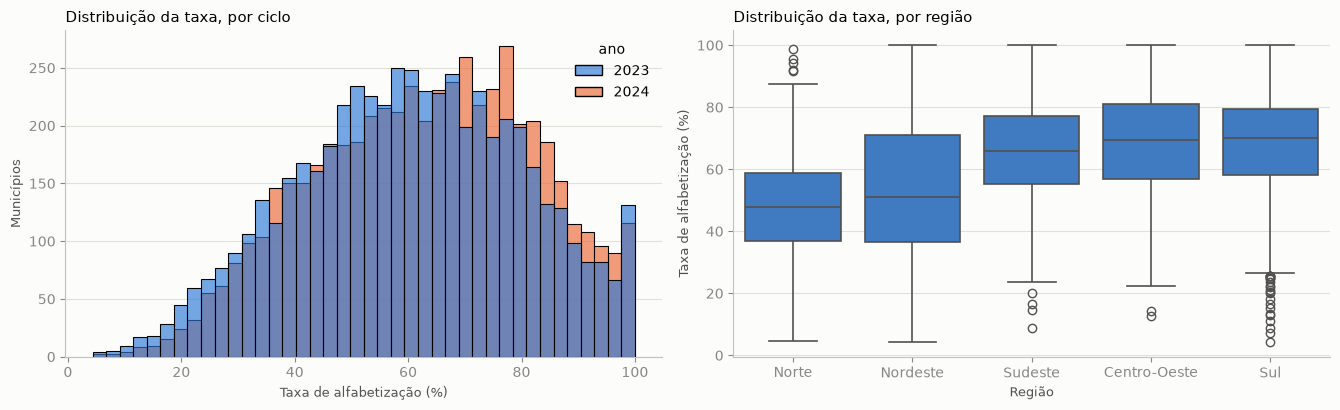

In [8]:
# ============================================================
# 3.1 — HISTOGRAMA E BOXPLOT POR REGIÃO
# ============================================================

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.2))

sns.histplot(data=base, x="taxa_alfabetizacao", hue="ano", bins=40,
             palette=[SERIE[0], SERIE[1]], ax=eixos[0], alpha=0.65)
eixos[0].set_title("Distribuição da taxa, por ciclo", loc="left")
eixos[0].set_xlabel("Taxa de alfabetização (%)"); eixos[0].set_ylabel("Municípios")

ordem = base.groupby("regiao")["taxa_alfabetizacao"].median().sort_values().index
sns.boxplot(data=base, x="regiao", y="taxa_alfabetizacao", order=ordem,
            color=SERIE[0], ax=eixos[1], linecolor=TINTA_2, linewidth=1.2)
eixos[1].set_title("Distribuição da taxa, por região", loc="left")
eixos[1].set_xlabel("Região"); eixos[1].set_ylabel("Taxa de alfabetização (%)")

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "02_distribuicao_alvo", IMAGENS); plt.show()

**O que isso decide.**

A taxa é **aproximadamente simétrica** e ocupa quase toda a faixa possível, com ~1% das linhas em
100% e ~1,5% abaixo de 20%. Sem empilhamento nos extremos, um corte binário é viável e a regressão
logística não sofrerá de separação perfeita.

A média subiu de **60,3% para 62,8%** entre os ciclos, mas o boxplot mostra que **a média nacional
esconde o problema**: a dispersão dentro de cada região é enorme. Um modelo que acerte a média e
erre a cauda é inútil para política pública — é o município da cauda inferior que precisa de
intervenção.

**Decisão de métricas:** com o corte em 50%, a classe de risco fica minoritária (27%), e um modelo
que responda "fora de risco" para todo mundo já acerta 73%. A avaliação priorizará **PR-AUC e
recall da classe de risco**, com ROC-AUC e calibração — nunca acurácia sozinha.

## Etapa 4 — Análise por estado: o território explica quanto?

A hipótese mais óbvia, e por isso a primeira a testar.

In [9]:
# ============================================================
# 4. ANÁLISE POR REGIÃO E POR UF
# ============================================================

por_regiao = (base.pivot_table(index="regiao", columns="ano",
                               values="taxa_alfabetizacao", aggfunc="mean")
              .round(1))
por_regiao["variação"] = (por_regiao[2024] - por_regiao[2023]).round(1)
por_regiao.sort_values(2024, ascending=False)

ano,2023,2024,variação
regiao,,,
Centro-Oeste,64.5,72.3,7.8
Sudeste,62.2,70.0,7.8
Sul,72.2,63.8,-8.4
Nordeste,53.1,56.3,3.2
Norte,45.8,49.4,3.6


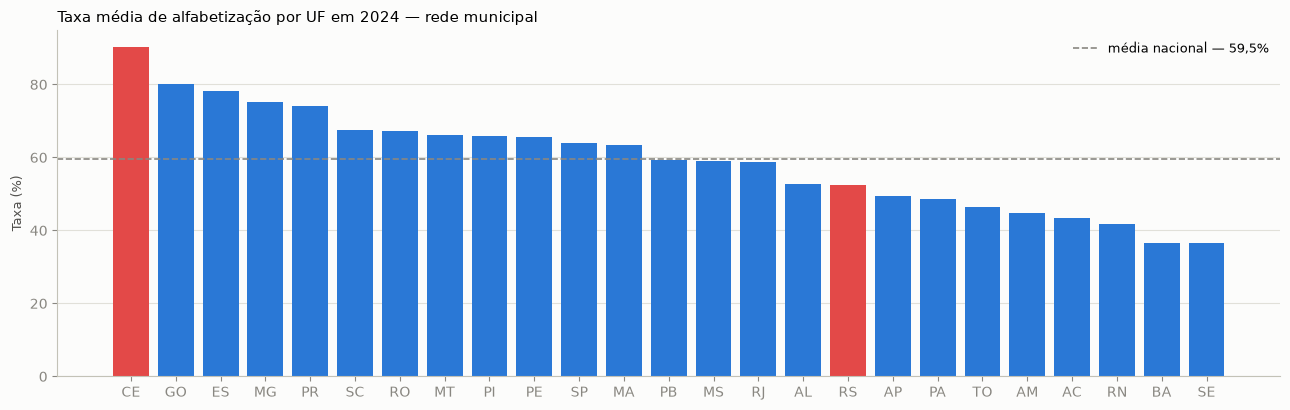

Amplitude entre a maior e a menor UF: 53,9 pontos percentuais


In [10]:
# ============================================================
# 4.1 — GRÁFICO DE BARRAS POR UF, ORDENADO
# ============================================================

por_uf = (base[base["ano"] == 2024].groupby("sigla_uf")["taxa_alfabetizacao"]
          .mean().sort_values(ascending=False))

fig, eixo = plt.subplots(figsize=(13, 4.2))
cores = [NEGATIVO if uf in ("CE", "RS") else SERIE[0] for uf in por_uf.index]
eixo.bar(por_uf.index, por_uf.values, color=cores)
eixo.axhline(por_uf.mean(), color=MUDO, linestyle="--", linewidth=1.2,
             label=f"média nacional — {num(por_uf.mean(), 1)}%")
eixo.set_title("Taxa média de alfabetização por UF em 2024 — rede municipal", loc="left")
eixo.set_ylabel("Taxa (%)"); eixo.legend(fontsize=9)
limpar(eixo)
fig.tight_layout(); salvar(fig, "02_variacao_por_uf", IMAGENS); plt.show()

print(f"Amplitude entre a maior e a menor UF: "
      f"{num(por_uf.max() - por_uf.min(), 1)} pontos percentuais")

In [11]:
# ============================================================
# 4.2 — INVESTIGANDO A QUEDA DO SUL
# ============================================================

pivo = base.pivot_table(index=["sigla_uf", "id_municipio"], columns="ano",
                        values="taxa_alfabetizacao").dropna()
pivo["delta"] = pivo[2024] - pivo[2023]

variacao_uf = (pivo.groupby("sigla_uf")["delta"]
               .agg(municipios="size", variacao_media="mean",
                    mediana="median", pct_em_queda=lambda s: (s < 0).mean() * 100)
               .round(1).sort_values("variacao_media"))
variacao_uf.head(6)

,municipios,variacao_media,mediana,pct_em_queda
sigla_uf,,,,
RS,443,-20.0,-19.9,89.6
PR,398,-1.7,-1.8,62.6
AM,62,-1.4,-2.6,58.1
BA,407,-0.9,-0.8,54.1
CE,184,0.3,0.3,43.5
SC,289,1.2,1.7,45.3


A amplitude entre regiões é de **quase 23 pontos percentuais** — maior que o efeito de qualquer
variável isolada que veremos adiante. Mas a coluna `variação` revela algo fora do roteiro: **todas
as regiões melhoraram entre 2023 e 2024, exceto o Sul**.

**A queda é sistêmica, não amostral.** Quase 90% dos municípios gaúchos caíram, com mediana de
**−19,9 p.p.** As outras UFs negativas recuaram menos de 2 pontos — variação normal entre ciclos.

**Hipótese:** as enchentes de abril-maio de 2024 interromperam o calendário letivo na janela do
ciclo avaliativo. É plausível e consistente com o padrão, **mas não é comprovável com esta base**,
que não traz calendário escolar nem ocorrência de desastre. Fica registrada como hipótese.

**O que isso decide.** Um choque desse porte quebra a suposição de que os dois ciclos são
intercambiáveis. A modelagem se ancora **no ciclo de 2024**, usando 2023 apenas como *histórico*.

**A contrapartida é declarada:** para o RS o modelo vê um histórico bom (pré-choque) e um
resultado ruim (pós-choque), e lê a diferença como estrutura. **O risco previsto para o estado
fica superestimado** — limitação que acompanha os notebooks 03 e 04.

## Etapa 5 — Correlações com o alvo: o enriquecimento externo valeu a pena?

Removidas as colunas que vazavam, sobraram quatro variáveis do INEP original. **Todo o poder
preditivo restante precisa vir das fontes externas.** Pearson mede associação linear; Spearman é
monotônica e robusta a extremos, o que importa num alvo limitado a [0, 100].

In [12]:
# ============================================================
# 5. CORRELAÇÕES COM O ALVO
# ============================================================

numericas = base.select_dtypes(include=[np.number]).drop(columns=["ano"])
correlacoes = pd.DataFrame({
    "pearson": numericas.corr(method="pearson")["taxa_alfabetizacao"],
    "spearman": numericas.corr(method="spearman")["taxa_alfabetizacao"],
}).drop(index="taxa_alfabetizacao")

correlacoes["magnitude"] = correlacoes["spearman"].abs()
correlacoes.sort_values("magnitude", ascending=False).head(12).round(3)

,pearson,spearman,magnitude
ideb_2021,0.530,0.519,0.519
nota_matematica_2021,0.516,0.513,0.513
nota_portugues_2021,0.507,0.499,0.499
inse_pc_nivel_1,-0.232,-0.309,0.309
media_inse,0.298,0.290,0.290
inse_pc_nivel_2,-0.278,-0.289,0.289
inse_pc_nivel_6,0.269,0.268,0.268
afd_ai_grupo_5,-0.231,-0.266,0.266
inse_pc_nivel_3,-0.264,-0.266,0.266
taxa_aprovacao_2021,0.248,0.263,0.263


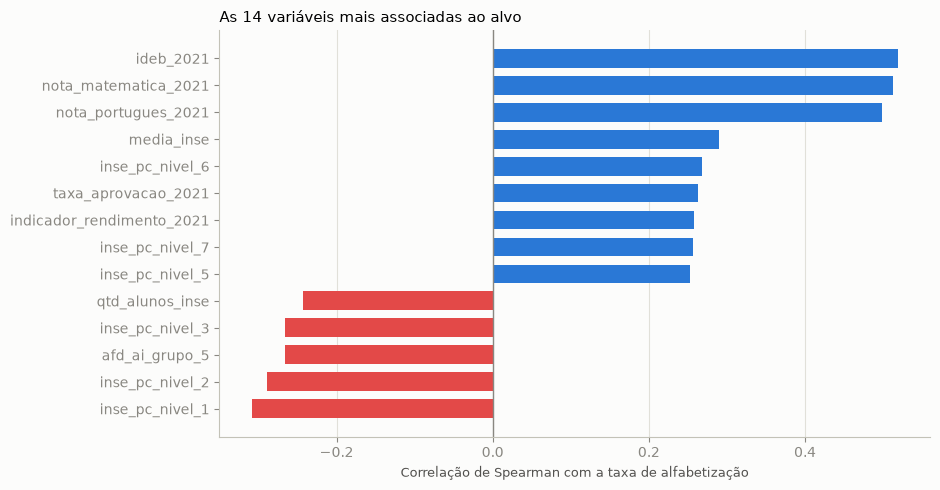

In [13]:
# ============================================================
# 5.1 — GRÁFICO DAS CORRELAÇÕES
# ============================================================

principais = correlacoes.sort_values("magnitude", ascending=False).head(14)
principais = principais.sort_values("spearman")

fig, eixo = plt.subplots(figsize=(9.5, 5.0))
eixo.barh(principais.index, principais["spearman"],
          color=[NEGATIVO if v < 0 else SERIE[0] for v in principais["spearman"]], height=0.7)
eixo.axvline(0, color=MUDO, linewidth=1)
eixo.set_xlabel("Correlação de Spearman com a taxa de alfabetização")
eixo.set_title("As 14 variáveis mais associadas ao alvo", loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "02_correlacoes_alvo", IMAGENS); plt.show()

**O que isso decide.**

O **IDEB de 2021 domina** (0,53) — o preditor mais forte da base, e legítimo porque foi publicado
dois anos antes. O bloco **socioeconômico** vem em seguida (`media_inse` 0,30), com os níveis do
INSE se comportando como esperado: os baixos negativos, os altos positivos. A **formação docente**
aparece na direção correta: `afd_ai_grupo_1` positivo e `afd_ai_grupo_5` negativo.

**A conclusão que valida o notebook 01:** sem enriquecimento, a correlação máxima seria a de `ano`
(0,06); com ele, 0,53. E nenhuma passa disso — um preditor isolado com 0,95 seria sinal de
vazamento, não de qualidade.

## Etapa 6 — Confundimento: o gradiente socioeconômico é geográfico?

`media_inse` correlaciona 0,30 com o alvo, e a tentação é ler "municípios mais pobres alfabetizam
menos". Antes de aceitar, vale checar se o INSE não está medindo **outra coisa**.

In [14]:
# ============================================================
# 6. O DECIL DE INSE É UM RÓTULO DE REGIÃO?
# ============================================================

recorte = base.dropna(subset=["media_inse"]).copy()
recorte["decil_nacional"] = pd.qcut(recorte["media_inse"], 10, labels=False) + 1

pd.crosstab(recorte["decil_nacional"], recorte["regiao"])

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
decil_nacional,,,,,
1,4,822,231,26,0
2,2,924,118,35,3
3,2,915,109,55,2
4,22,745,154,149,11
5,192,162,178,486,64
6,276,4,44,551,208
7,232,0,8,547,299
8,112,0,4,603,358
9,60,0,0,533,489


In [15]:
# ============================================================
# 6.1 — SPEARMAN INSE x TAXA, DENTRO DE CADA REGIÃO
# ============================================================

por_regiao_corr = (recorte.groupby("regiao")
                   .apply(lambda g: g["media_inse"].corr(g["taxa_alfabetizacao"],
                                                         method="spearman"))
                   .sort_values(ascending=False).round(3))

agregado = recorte["media_inse"].corr(recorte["taxa_alfabetizacao"], method="spearman")
print(f"Spearman agregado (nacional): {agregado:.3f}\n")
por_regiao_corr.to_frame("spearman_intrarregional")

Spearman agregado (nacional): 0.290



,spearman_intrarregional
regiao,
Norte,0.310
Centro-Oeste,0.199
Sul,0.044
Sudeste,0.006
Nordeste,-0.135


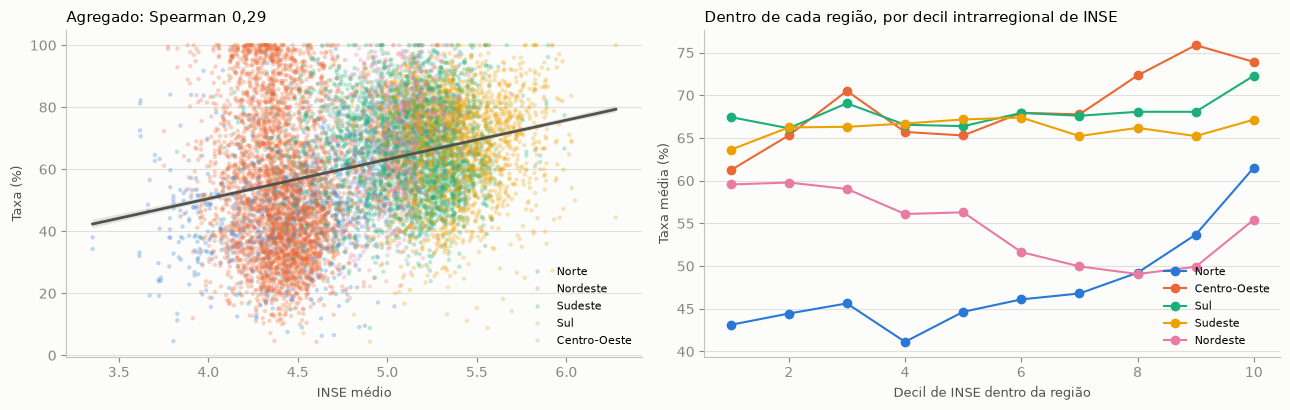

In [16]:
# ============================================================
# 6.2 — VISUALIZANDO O PARADOXO DE SIMPSON
# ============================================================

recorte["decil_regional"] = (recorte.groupby("regiao")["media_inse"]
                             .transform(lambda s: pd.qcut(s, 10, labels=False, duplicates="drop") + 1))

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2))

sns.regplot(data=recorte, x="media_inse", y="taxa_alfabetizacao", scatter=False,
            color=TINTA_2, ax=eixos[0], line_kws={"linewidth": 2})
sns.scatterplot(data=recorte, x="media_inse", y="taxa_alfabetizacao", hue="regiao",
                alpha=0.28, s=10, ax=eixos[0], palette=SERIE[:5], edgecolor="none")
eixos[0].set_title(f"Agregado: Spearman {num(agregado, 2)}", loc="left")
eixos[0].set_xlabel("INSE médio"); eixos[0].set_ylabel("Taxa (%)")
eixos[0].legend(fontsize=8, title=None)

for i, regiao in enumerate(por_regiao_corr.index):
    linha = (recorte[recorte["regiao"] == regiao]
             .groupby("decil_regional")["taxa_alfabetizacao"].mean())
    eixos[1].plot(linha.index, linha.values, marker="o", color=SERIE[i], label=regiao)
eixos[1].set_title("Dentro de cada região, por decil intrarregional de INSE", loc="left")
eixos[1].set_xlabel("Decil de INSE dentro da região"); eixos[1].set_ylabel("Taxa média (%)")
eixos[1].legend(fontsize=8)

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "02_confundimento_regional", IMAGENS); plt.show()

In [17]:
# ============================================================
# 6.3 — O CASO CEARÁ x PERNAMBUCO
# ============================================================

comparacao = (base[(base["ano"] == 2024) & (base["sigla_uf"].isin(["CE", "PE", "SP", "SC"]))]
              .groupby("sigla_uf")
              .agg(municipios=("id_municipio", "size"),
                   inse_medio=("media_inse", "mean"),
                   taxa_media=("taxa_alfabetizacao", "mean"))
              .round(2).sort_values("taxa_media", ascending=False))
comparacao

,municipios,inse_medio,taxa_media
sigla_uf,,,
CE,184,4.37,90.31
SC,289,5.48,67.47
PE,184,4.37,65.58
SP,626,5.28,64.03


**O achado.** A tabela de decis já responde a primeira pergunta: **o decil nacional de INSE é quase
um rótulo de região.** Os decis mais baixos quase não têm municípios do Sul; os mais altos não têm
*nenhum* do Nordeste. Comparar o decil 1 com o 10 é comparar Nordeste com Sul.

Calculando o decil **dentro de cada região**, o gradiente agregado (Spearman **0,29**) **não se
sustenta**: forte no Norte (0,31), moderado no Centro-Oeste (0,20), praticamente ausente no Sul
(0,04) e no Sudeste (0,01) — e **invertido no Nordeste (−0,14)**. Nas duas regiões que concentram
63% da base, o nível socioeconômico **não ordena** o desempenho. Removendo o Ceará, o Nordeste
segue negativo (−0,11): não é artefato de um estado. É um **paradoxo de Simpson** de manual.

**E o caso que fecha o argumento:** Ceará e Pernambuco têm INSE praticamente idêntico e taxas
separadas por 27 pontos percentuais. O Ceará supera São Paulo e Santa Catarina com INSE muito
inferior — e é o estado com a política de alfabetização mais antiga do país (o PAIC, de 2007,
serviu de referência para o próprio CNCA). O dado é consistente com a tese que dá sentido ao
projeto: **gestão e política pública podem superar a condição socioeconômica.**

**O que isso decide.**

1. `sigla_uf` entra no modelo como categórica (one-hot) — controle obrigatório, não cosmético:
   sem ele o coeficiente de `media_inse` viria enviesado.
2. **Advertência de narrativa:** não afirmar que "o nível socioeconômico determina a
   alfabetização". O dado não sustenta isso.
3. **Limite honesto:** a base não contém nenhuma variável de política educacional. O efeito do
   Ceará será absorvido pela dummy de UF sem que o modelo saiba *por quê*.

## Etapa 7 — Multicolinearidade: dois problemas de naturezas diferentes

Preditores redundantes deixam os coeficientes instáveis e destroem a interpretação em *odds
ratio*, que é o motivo de escolhermos a Regressão Logística.

In [18]:
# ============================================================
# 7. BLOCOS COMPOSICIONAIS — SOMAM 100%?
# ============================================================

blocos = {
    "AFD (formação docente)": [f"afd_ai_grupo_{i}" for i in range(1, 6)],
    "IED (esforço docente)": [f"ied_ai_nivel_{i}" for i in range(1, 7)],
    "INSE (níveis)": [f"inse_pc_nivel_{i}" for i in range(1, 9)],
}
pd.DataFrame([{"bloco": nome, "variáveis": len(cols),
               "soma média": round(float(base[cols].sum(axis=1).mean()), 2),
               "desvio da soma": round(float(base[cols].sum(axis=1).std()), 2)}
              for nome, cols in blocos.items()])

,bloco,variáveis,soma média,desvio da soma
0,AFD (formação docente),5,99.94,2.53
1,IED (esforço docente),6,100.00,0.00
2,INSE (níveis),8,99.31,8.27


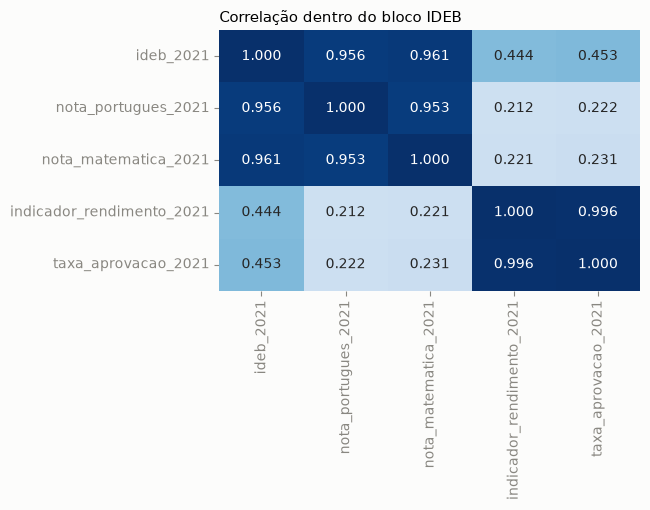

In [19]:
# ============================================================
# 7.1 — HEATMAP DE CORRELAÇÃO DO BLOCO IDEB
# ============================================================

bloco_ideb = ["ideb_2021", "nota_portugues_2021", "nota_matematica_2021",
              "indicador_rendimento_2021", "taxa_aprovacao_2021"]

fig, eixo = plt.subplots(figsize=(6.6, 5.2))
sns.heatmap(base[bloco_ideb].corr().round(3), annot=True, fmt=".3f",
            cmap="Blues", vmin=0, vmax=1, cbar=False, ax=eixo,
            annot_kws={"fontsize": 10})
eixo.set_title("Correlação dentro do bloco IDEB", loc="left")
fig.tight_layout(); salvar(fig, "02_multicolinearidade_ideb", IMAGENS); plt.show()

**Problema 1 — blocos composicionais.** AFD, IED e INSE são percentuais que somam 100%. A última
categoria de cada bloco é `100 − (soma das demais)`: colinearidade perfeita, informação zero.
**Decisão:** descartar uma **categoria de referência** por bloco — `afd_ai_grupo_5` (sem curso
superior), `ied_ai_nivel_1` (menor esforço) e `inse_pc_nivel_1` (nível mais baixo). Cada
coeficiente passa a ser "efeito de deslocar um ponto percentual da referência para esta".

**Problema 2 — redundância no bloco IDEB.** Dois agrupamentos quase perfeitos: `ideb_2021` e as
duas notas correlacionam **0,953 a 0,961** entre si (o IDEB é composição delas); e
`indicador_rendimento_2021` com `taxa_aprovacao_2021` correlacionam **0,996** — a mesma variável
em escalas diferentes. **Decisão:** manter `ideb_2021` (índice composto, interpretável) e
`taxa_aprovacao_2021` (fluxo escolar, dimensão distinta), com **regularização L2** como
salvaguarda.

## Etapa 8 — Persistência temporal: o passado do município prevê o presente?

Cada município aparece nos dois ciclos. A correlação entre a sua taxa em 2023 e em 2024 responde a
duas perguntas de uma vez: quanto o passado prevê o presente, e quanto risco de memorização existe
se o mesmo município atravessar a fronteira treino/validação.

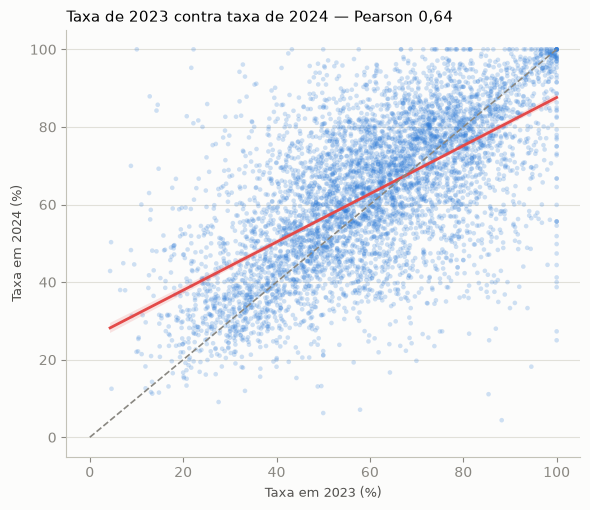

Municípios em ambos os ciclos: 5396
Municípios distintos na base : 5500


In [20]:
# ============================================================
# 8. PERSISTÊNCIA ENTRE OS CICLOS
# ============================================================

# Nomes de coluna precisam ser texto para o seaborn — o pivot devolveu inteiros
pareado = pivo.reset_index().rename(columns={2023: "taxa_2023", 2024: "taxa_2024"})
correlacao = pareado["taxa_2023"].corr(pareado["taxa_2024"])

fig, eixo = plt.subplots(figsize=(6.0, 5.2))
sns.scatterplot(data=pareado, x="taxa_2023", y="taxa_2024", alpha=0.22, s=11,
                color=SERIE[0], edgecolor="none", ax=eixo)
sns.regplot(data=pareado, x="taxa_2023", y="taxa_2024", scatter=False, color=NEGATIVO,
            ax=eixo, line_kws={"linewidth": 2})
eixo.plot([0, 100], [0, 100], color=MUDO, linestyle="--", linewidth=1.2)
eixo.set_title(f"Taxa de 2023 contra taxa de 2024 — Pearson {num(correlacao, 2)}", loc="left")
eixo.set_xlabel("Taxa em 2023 (%)"); eixo.set_ylabel("Taxa em 2024 (%)")
limpar(eixo)
fig.tight_layout(); salvar(fig, "02_persistencia_temporal", IMAGENS); plt.show()

print(f"Municípios em ambos os ciclos: {len(pareado)}")
print(f"Municípios distintos na base : {base['id_municipio'].nunique()}")

**Duas conclusões.**

A correlação de **0,64** é, ao mesmo tempo, a **justificativa do bloco histórico** e um alerta. É
alta o bastante para que a taxa de 2023 seja o melhor preditor disponível da taxa de 2024 — e é
por isso que ela entra no modelo, defasada e portanto legítima. E é alta o bastante para exigir que
um mesmo município **nunca** apareça em treino e validação ao mesmo tempo.

E uma descoberta que **corrige uma imprecisão do notebook 01**: há 5.448 linhas em cada ciclo, mas
**5.500 municípios distintos** — apenas **5.396** aparecem nos dois. Os municípios do Acre só
existem em 2024. São esses 5.396 que formam o painel de modelagem, já que o histórico é
obrigatório.

## Etapa 9 — Hipóteses analíticas e decisões de modelagem

### As cinco hipóteses

Registrá-las **antes** de treinar é o que impede reescrever a expectativa depois de ver o
resultado. O [notebook 03](03_modelagem.ipynb) as testa.

| # | Hipótese | Evidência nesta EDA | Como será testada |
|---|---|---|---|
| **H1** | O desempenho pregresso é o melhor preditor disponível | IDEB 2021 tem a maior correlação (0,53); a taxa de 2023 persiste 0,64 | permutation importance do bloco histórico |
| **H2** | O efeito socioeconômico é menor do que a correlação bruta sugere — boa parte é geografia | dentro das regiões, Spearman cai de 0,29 para 0,01 (Sudeste) e −0,14 (Nordeste) | coeficiente de `media_inse` com as dummies de UF |
| **H3** | A qualificação docente tem efeito próprio | `afd_ai_grupo_1` e `afd_ai_grupo_5` com sinais opostos e magnitude semelhante | sinal e magnitude do bloco AFD no modelo completo |
| **H4** | Há efeito de gestão estadual que as variáveis não capturam | Ceará e Pernambuco: mesmo INSE, 27 p.p. de diferença | coeficientes das dummies de UF após controlar tudo o mais |
| **H5** | Municípios rurais e pequenos em desvantagem | `proporcao_rural` correlaciona negativamente; a ausência de IDEB se concentra nos pequenos | coeficientes de `proporcao_rural` e `capital_desc` |

### As decisões que esta EDA fixou

| Decisão | Etapa |
|---|---|
| Alvo binário `em_risco = taxa < 50%` — o corte cai em região densa da distribuição | 3 |
| Métricas: PR-AUC e recall da classe de risco, com ROC-AUC e calibração — nunca acurácia sozinha | 3 |
| Modelar 2024 com 2023 como histórico, em vez de empilhar os dois ciclos | 4 |
| Risco previsto para o RS declarado como superestimado pelo choque de 2024 | 4 |
| `sigla_uf` como categórica — controle obrigatório, não cosmético | 6 |
| Descartar uma categoria de referência em cada bloco composicional | 7 |
| Do bloco IDEB, manter `ideb_2021` e `taxa_aprovacao_2021`; regularização L2 | 7 |
| `StandardScaler` e imputação dentro do `Pipeline`, com `add_indicator` no IDEB | 2 |
| `train_test_split` estratificado + `StratifiedKFold` de 5 folds, uma linha por município | 8 |

**Próximo passo:** [03 — modelagem supervisionada](03_modelagem.ipynb).